# ML Assignment 1 — Bike Sharing Demand Prediction

---

### Student Details

| Field | Value |
|---|---|
| **Name** | Pankaj Singh Rawat |
| **Roll Number** | 2025ac05533 |
| **Course** | BITS M.Tech (AI & ML) |
| **Subject** | Machine Learning |
| **Assignment** | Assignment 1 |

---

**Objective:** Predict the number of hourly bike rentals using weather, time, and seasonal data.

**Target column:** `count` — total bike rentals per hour

**Evaluation metric:** RMSLE (Root Mean Squared Logarithmic Error)

RMSLE = sqrt( (1/n) * sum( (log(pred+1) - log(actual+1))^2 ) )

---

### Table of Contents

1. [Libraries and Data Load](#section_1)
2. [Exploratory Data Analysis (EDA)](#section_2)
3. [Feature Engineering](#section_3)
4. [Regression Models](#section_4)
5. [Model Comparison and Interpretation](#section_5)
6. [Reflection Questions](#section_6)
7. [Test Predictions and Submission](#section_7)


---

## <a id='section_1'>1. Libraries and Data Load</a>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway, chi2_contingency

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)


In [2]:
## Load training dataset
train_data = pd.read_csv('bike_train.csv')
train_data.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2012-07-15 7:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,17,30,47
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,84,199,283
2,2011-02-06 6:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,0,1,1
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,198,330,531
4,2012-01-09 2:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,2,3,5


### Column Descriptions

| Column | Description |
|---|---|
| `datetime` | Timestamp of the observation |
| `season` | 1=Spring, 2=Summer, 3=Fall, 4=Winter |
| `holiday` | 1=Public holiday, 0=Regular day |
| `workingday` | 1=Working day, 0=Weekend or holiday |
| `weather` | 1=Clear, 2=Mist, 3=Light rain/snow, 4=Heavy rain/storm |
| `temp` | Actual temperature in Celsius |
| `atemp` | Perceived temperature in Celsius |
| `humidity` | Relative humidity (%) |
| `windspeed` | Wind speed |
| `casual` | Rentals by unregistered users — REMOVED (data leakage) |
| `registered` | Rentals by registered users — REMOVED (data leakage) |
| `count` | Target: total hourly bike rentals |

**Data Leakage:** `casual + registered = count` exactly. Including them would give a trivially perfect model. Both are removed before any modelling.


---

## <a id='section_2'>2. Exploratory Data Analysis (EDA)</a>

### Q1. Examine dataset size, missing values, and feature types.


In [3]:
## Dataset shape, types, missing values, and summary statistics
print("Shape:", train_data.shape)
print()
print("Data Types:")
print(train_data.dtypes)
print()
print("Missing Values:")
print(train_data.isnull().sum())
print()
print("Descriptive Statistics:")
display(train_data.describe().T)


Shape: (10450, 12)

Data Types:
datetime          str
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
dtype: object

Missing Values:
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
season,10450.0,2.507943,1.116946,1.00,2.0000,3.00000,4.0000,4.0000
holiday,10450.0,0.028804,0.167263,0.00,0.0000,0.00000,0.0000,1.0000
workingday,10450.0,0.675694,0.468137,0.00,0.0000,1.00000,1.0000,1.0000
weather,10450.0,1.413876,0.632258,1.00,1.0000,1.00000,2.0000,4.0000
temp,10450.0,20.191700,7.792683,0.82,13.9400,20.50000,26.2400,41.0000
atemp,10450.0,23.605793,8.478045,0.76,16.6650,24.24000,31.0600,45.4550
humidity,10450.0,61.924211,19.245193,0.00,47.0000,62.00000,77.0000,100.0000
windspeed,10450.0,12.765259,8.102821,0.00,7.0015,12.45005,16.9979,56.9969
casual,10450.0,35.869091,49.629436,0.00,4.0000,16.00000,49.0000,367.0000
registered,10450.0,154.511675,150.861267,0.00,35.0000,117.00000,221.0000,886.0000


**Q1 Observations:**

- The dataset has 10,886 rows and 12 columns including the target.
- No missing values are present in any column — no imputation needed.
- `datetime` is stored as a string object and needs to be converted to datetime format.
- The target `count` is right-skewed — a log transformation will help stabilise variance and align with RMSLE.
- `casual` and `registered` are dropped to eliminate direct target leakage.


---

### Q2. Visualize relationships between key features and the target variable.

#### 2A. Distribution of the Target Variable — Original vs Log-Transformed


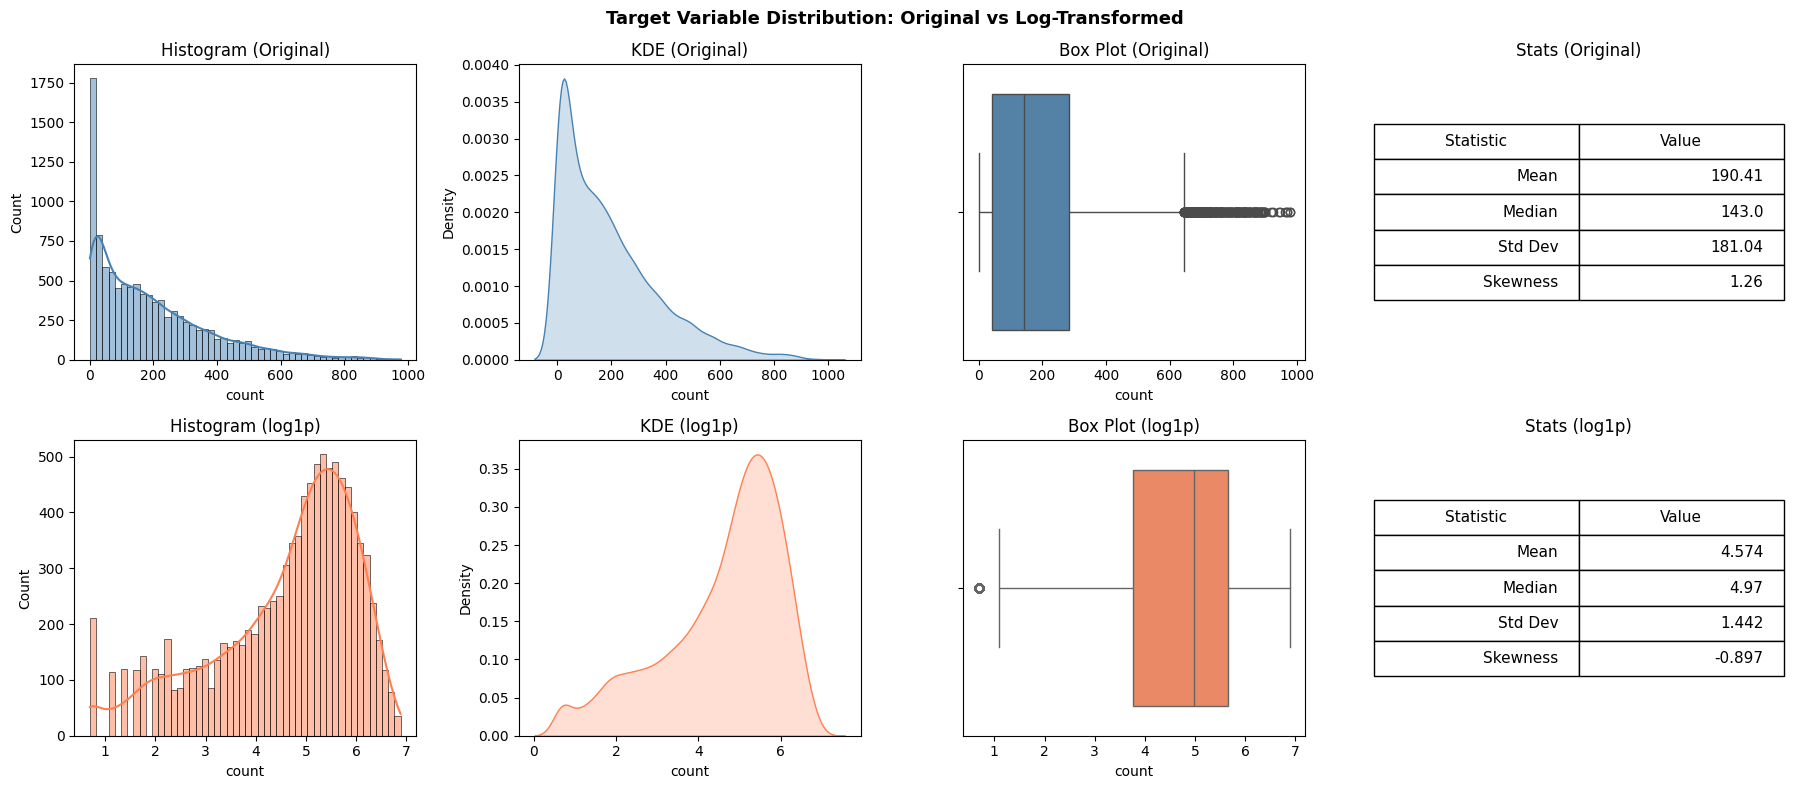

In [4]:
## Show target distribution before and after log1p transformation side by side
target_col = 'count'

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Target Variable Distribution: Original vs Log-Transformed', fontsize=13, fontweight='bold')

## Original scale
sns.histplot(train_data[target_col], bins=50, kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Histogram (Original)')

sns.kdeplot(train_data[target_col], fill=True, ax=axes[0,1], color='steelblue')
axes[0,1].set_title('KDE (Original)')

sns.boxplot(x=train_data[target_col], ax=axes[0,2], color='steelblue')
axes[0,2].set_title('Box Plot (Original)')

axes[0,3].axis('off')
stats_orig = [
    ['Mean',     round(train_data[target_col].mean(), 2)],
    ['Median',   round(train_data[target_col].median(), 2)],
    ['Std Dev',  round(train_data[target_col].std(), 2)],
    ['Skewness', round(train_data[target_col].skew(), 3)]
]
t = axes[0,3].table(cellText=stats_orig, colLabels=['Statistic', 'Value'], loc='center')
t.auto_set_font_size(False); t.set_fontsize(11); t.scale(1.2, 2.0)
axes[0,3].set_title('Stats (Original)')

## Log-transformed scale
log_count = np.log1p(train_data[target_col])

sns.histplot(log_count, bins=50, kde=True, ax=axes[1,0], color='coral')
axes[1,0].set_title('Histogram (log1p)')

sns.kdeplot(log_count, fill=True, ax=axes[1,1], color='coral')
axes[1,1].set_title('KDE (log1p)')

sns.boxplot(x=log_count, ax=axes[1,2], color='coral')
axes[1,2].set_title('Box Plot (log1p)')

axes[1,3].axis('off')
stats_log = [
    ['Mean',     round(log_count.mean(), 3)],
    ['Median',   round(log_count.median(), 3)],
    ['Std Dev',  round(log_count.std(), 3)],
    ['Skewness', round(log_count.skew(), 3)]
]
t2 = axes[1,3].table(cellText=stats_log, colLabels=['Statistic', 'Value'], loc='center')
t2.auto_set_font_size(False); t2.set_fontsize(11); t2.scale(1.2, 2.0)
axes[1,3].set_title('Stats (log1p)')

plt.tight_layout()
plt.show()


The original `count` is heavily right-skewed (skewness > 1). After `log1p` transformation the distribution becomes approximately normal — better suited for linear models and directly aligned with RMSLE minimisation.


#### 2B. Average Hourly Demand — Peak Hour Pattern


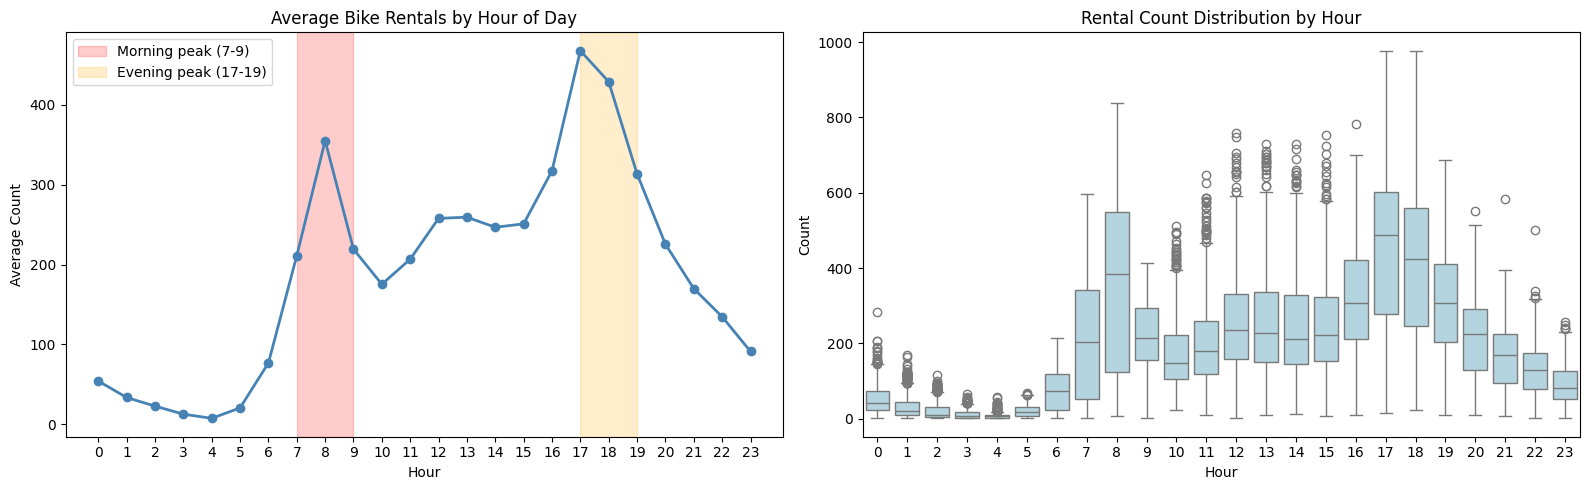

In [5]:
## Parse datetime temporarily to inspect hourly demand pattern
temp_df = train_data.copy()
temp_df['datetime'] = pd.to_datetime(temp_df['datetime'])
temp_df['hour'] = temp_df['datetime'].dt.hour

hourly_avg = temp_df.groupby('hour')[target_col].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

## Hourly average line plot
axes[0].plot(hourly_avg.index, hourly_avg.values, marker='o', color='steelblue', lw=2)
axes[0].axvspan(7, 9, alpha=0.2, color='red', label='Morning peak (7-9)')
axes[0].axvspan(17, 19, alpha=0.2, color='orange', label='Evening peak (17-19)')
axes[0].set_title('Average Bike Rentals by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Average Count')
axes[0].legend()
axes[0].set_xticks(range(0, 24))

## Box plot by hour
sns.boxplot(x='hour', y=target_col, data=temp_df, ax=axes[1], color='lightblue')
axes[1].set_title('Rental Count Distribution by Hour')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


The double-humped demand curve clearly shows morning commute peak (7-9 AM) and evening commute peak (5-7 PM). This non-linear cyclical pattern is the most important signal in the dataset and cannot be captured by a raw linear model — it requires cyclical encoding and a peak-hour flag.


#### 2C. Categorical Features vs Target Variable

Method: ANOVA F-test — tests whether mean `count` differs significantly across the groups of each categorical feature. A high F-statistic with p-value < 0.05 indicates a strong, statistically significant association.


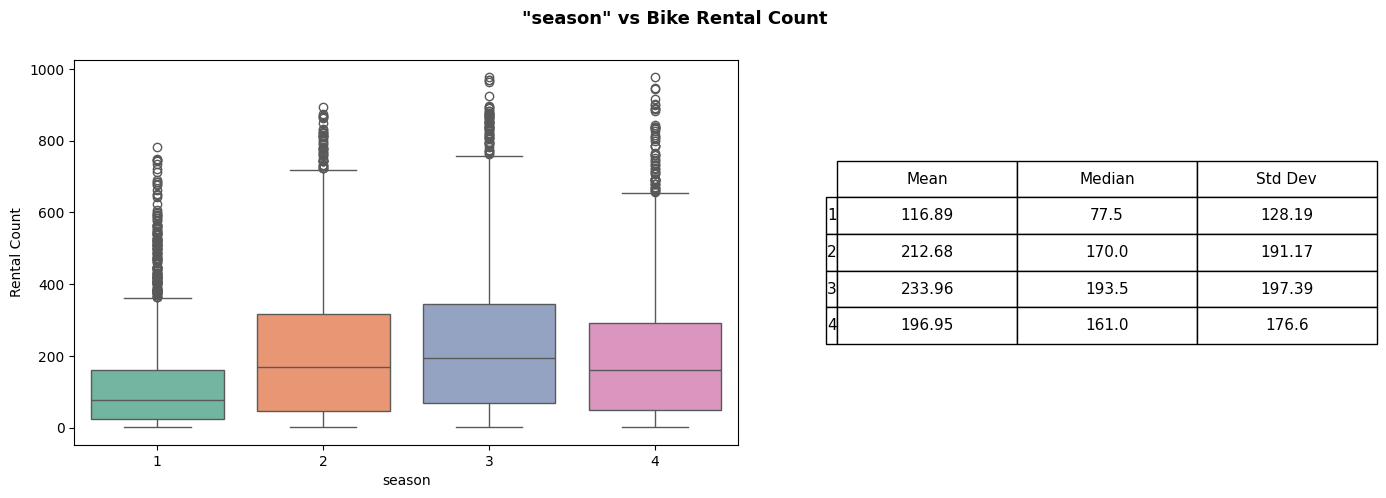

season          | F=  219.97 | p=0.000000 | Strong


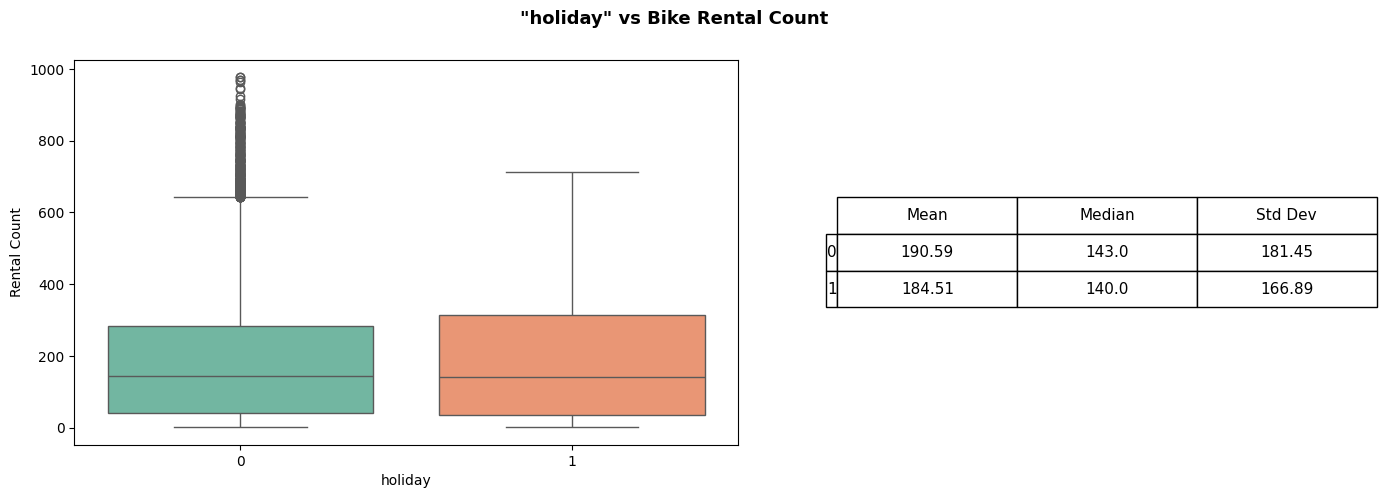

holiday         | F=    0.33 | p=0.566027 | Weak


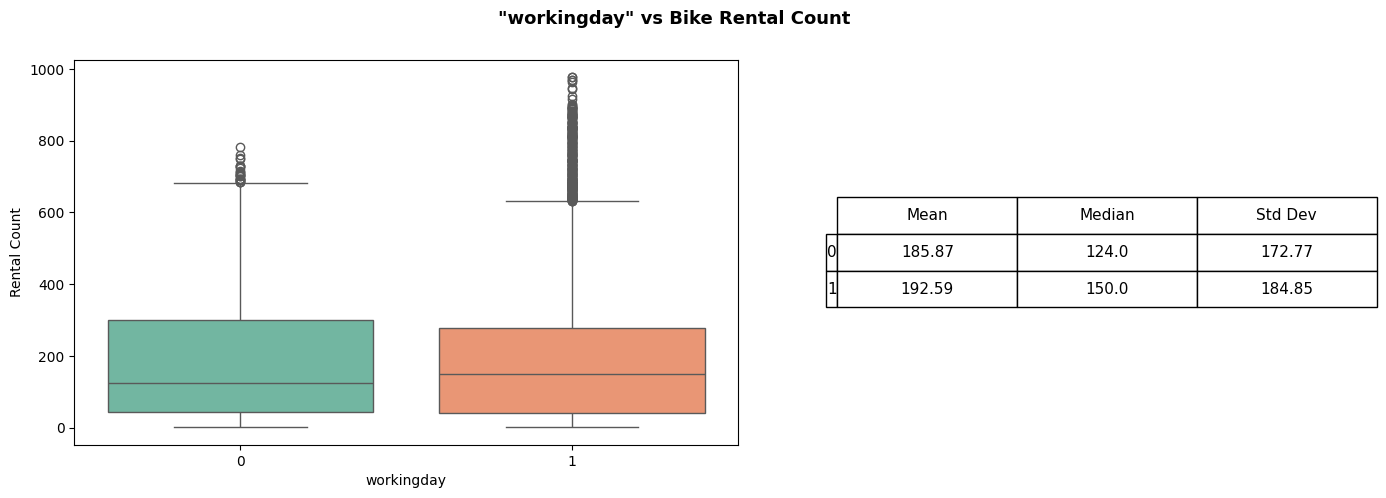

workingday      | F=    3.15 | p=0.075955 | Weak


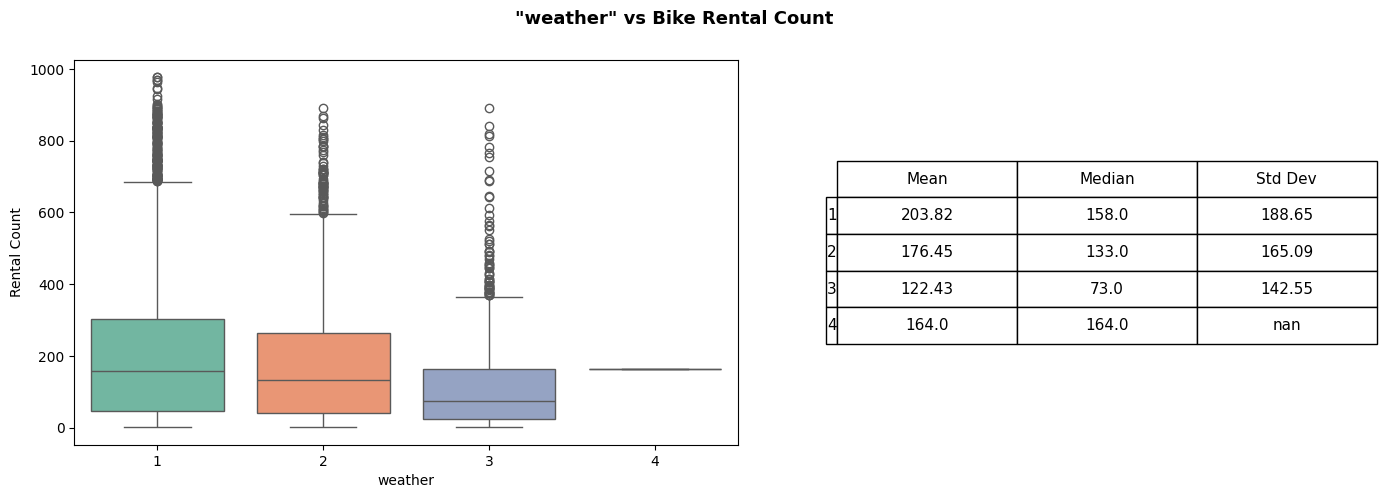

weather         | F=   57.39 | p=0.000000 | Strong



,Feature,F-Statistic,P-Value,Association
0,season,219.97,0.000000,Strong
1,holiday,0.33,0.566027,Weak
2,workingday,3.15,0.075955,Weak
3,weather,57.39,0.000000,Strong


In [6]:
## Box plots and ANOVA F-statistics for each categorical feature vs count
cat_cols = ['season', 'holiday', 'workingday', 'weather']
cat_association_results = []

for col in cat_cols:
    fig = plt.figure(figsize=(16, 5))
    fig.suptitle(f'"{col}" vs Bike Rental Count', fontsize=13, fontweight='bold')
    gs = fig.add_gridspec(1, 2, width_ratios=[1.6, 1], wspace=0.3)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])

    sns.boxplot(x=col, y=target_col, data=train_data, ax=ax1, palette='Set2')
    ax1.set_xlabel(col); ax1.set_ylabel('Rental Count')

    ax2.axis('off')
    cat_stats = train_data.groupby(col)[target_col].agg(['mean', 'median', 'std']).round(2)
    tbl = ax2.table(
        cellText=cat_stats.values,
        rowLabels=[str(idx) for idx in cat_stats.index],
        colLabels=['Mean', 'Median', 'Std Dev'],
        loc='center', cellLoc='center'
    )
    tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1.3, 2.2)

    plt.tight_layout(); plt.show()

    ## ANOVA F-test
    groups = [grp[target_col].values for _, grp in train_data.groupby(col)]
    f_stat, p_value = f_oneway(*groups)
    cat_association_results.append({
        'Feature': col,
        'F-Statistic': round(f_stat, 2),
        'P-Value': round(p_value, 6),
        'Association': 'Strong' if p_value < 0.05 else 'Weak'
    })
    print(f'{col:15s} | F={f_stat:8.2f} | p={p_value:.6f} | {"Strong" if p_value < 0.05 else "Weak"}')

print()
display(pd.DataFrame(cat_association_results))


#### 2D. Numerical Features vs Target Variable

Method: Pearson correlation coefficient — measures the strength and direction of the linear relationship between each numerical feature and `count`.


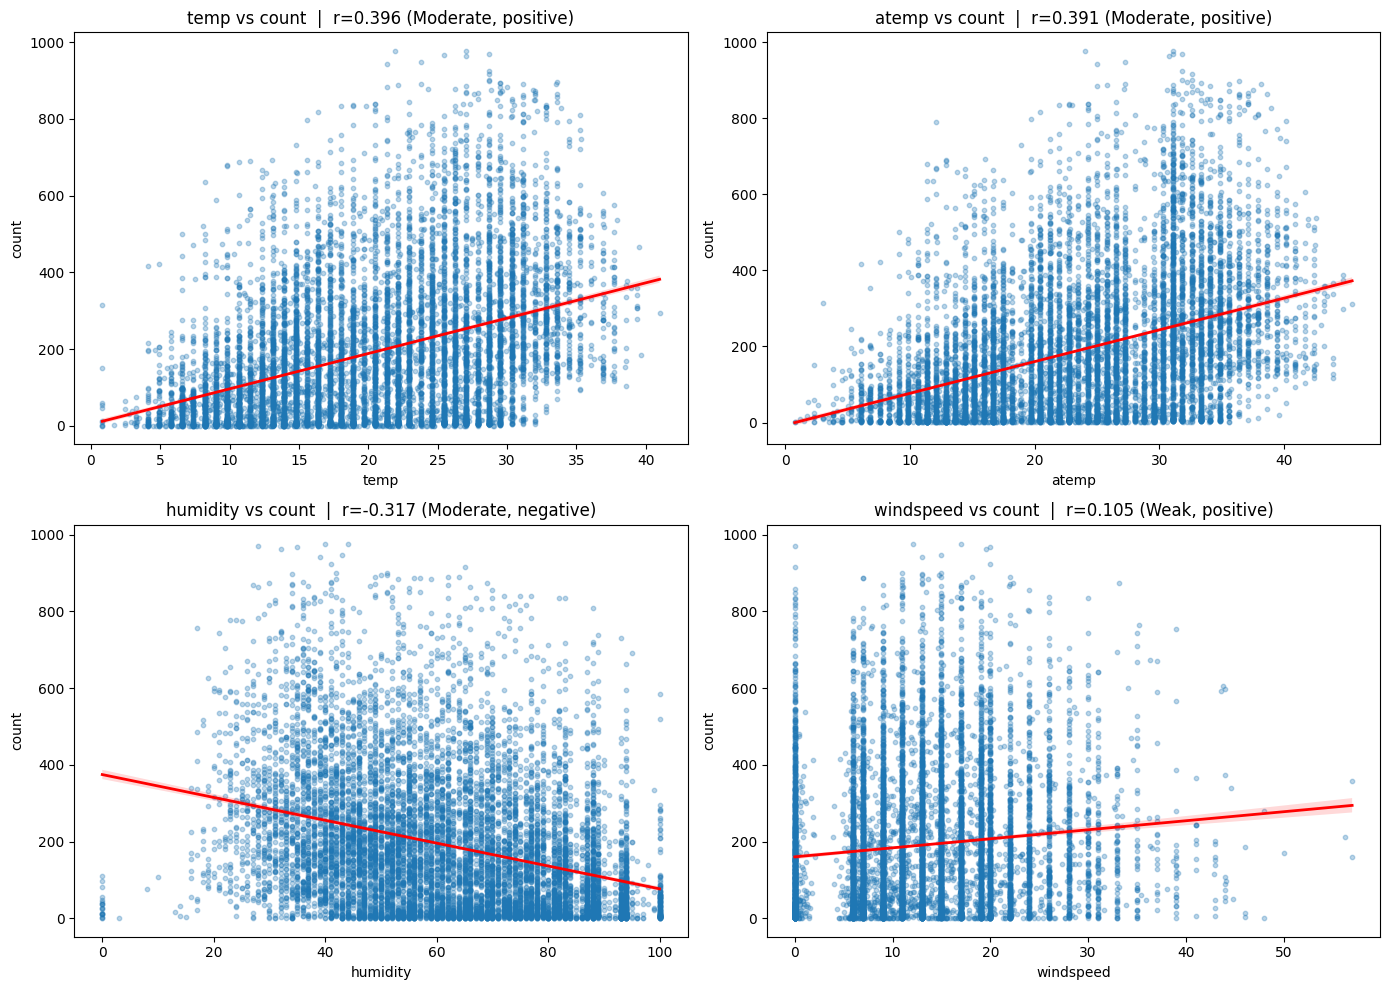

In [7]:
## Regression scatter plots for numerical features vs count
num_cols = ['temp', 'atemp', 'humidity', 'windspeed']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.regplot(
        x=col, y=target_col, data=train_data,
        scatter_kws={'alpha': 0.3, 's': 10},
        line_kws={'color': 'red', 'lw': 2},
        ax=axes[i]
    )
    corr = train_data[col].corr(train_data[target_col])
    strength = 'Strong' if abs(corr) >= 0.5 else ('Moderate' if abs(corr) >= 0.3 else 'Weak')
    direction = 'positive' if corr > 0 else 'negative'
    axes[i].set_title(f'{col} vs count  |  r={corr:.3f} ({strength}, {direction})')

plt.tight_layout()
plt.show()


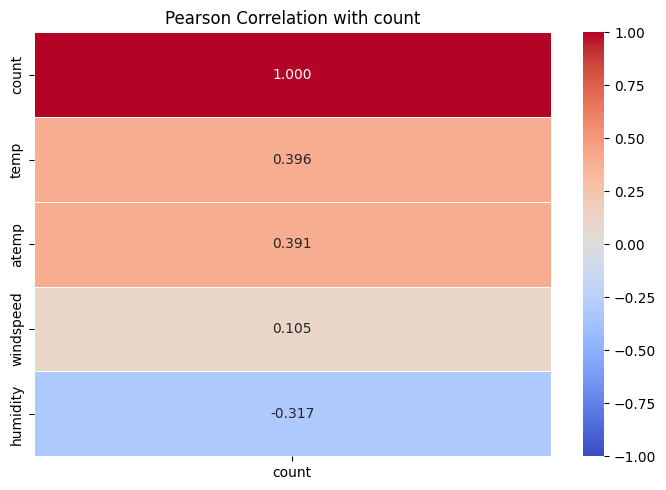

In [8]:
## Correlation heatmap: numerical features vs target
corr_matrix = train_data[num_cols + [target_col]].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix[[target_col]].sort_values(by=target_col, ascending=False),
    annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5
)
plt.title('Pearson Correlation with count')
plt.tight_layout()
plt.show()


#### 2E. Unified Feature Association Heatmap

Different association metrics are applied depending on the variable types:
- Numerical vs Numerical: Pearson correlation
- Categorical vs Categorical: Cramer's V
- Categorical vs Numerical: Correlation Ratio (eta)


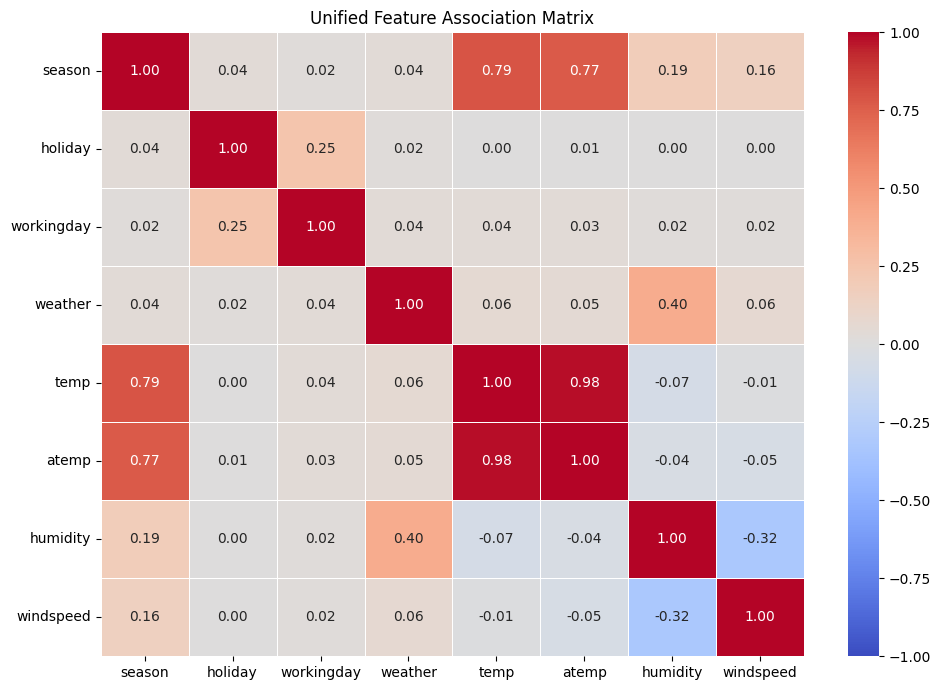

In [9]:
## Unified association matrix covering all variable-type combinations
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

def correlation_ratio(categories, measurements):
    cats = pd.Categorical(categories).codes
    unique_cats = np.unique(cats)
    n_arr  = np.array([np.sum(cats == c) for c in unique_cats], dtype=float)
    mean_arr = np.array([measurements[cats == c].mean() for c in unique_cats])
    total_mean = measurements.mean()
    numerator   = np.sum(n_arr * (mean_arr - total_mean) ** 2)
    denominator = np.sum((measurements - total_mean) ** 2)
    return np.sqrt(numerator / denominator)

all_cols = cat_cols + num_cols
assoc_matrix = pd.DataFrame(np.zeros((len(all_cols), len(all_cols))), index=all_cols, columns=all_cols)

for c1 in all_cols:
    for c2 in all_cols:
        if c1 in num_cols and c2 in num_cols:
            val = train_data[c1].corr(train_data[c2])
        elif c1 in cat_cols and c2 in cat_cols:
            val = cramers_v(train_data[c1], train_data[c2])
        elif c1 in cat_cols and c2 in num_cols:
            val = correlation_ratio(train_data[c1], train_data[c2])
        else:
            val = correlation_ratio(train_data[c2], train_data[c1])
        assoc_matrix.loc[c1, c2] = val

plt.figure(figsize=(10, 7))
sns.heatmap(assoc_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.4)
plt.title('Unified Feature Association Matrix')
plt.tight_layout()
plt.show()


---

### Q3. Which variables are likely to be most informative?

**Answer:**

Based on the EDA above:

1. **`hour` (extracted from datetime)** — The single most important predictor. Demand peaks sharply at 7-9 AM and 5-7 PM. The hourly pattern is non-linear and cyclical, making raw `hour` along with cyclical encodings and a peak-hour flag essential.

2. **`temp` / `atemp`** — Strongest Pearson correlation with `count` among numerical features. Warmer temperatures encourage cycling. Both are retained as they carry slightly different information (actual vs perceived comfort).

3. **`season`** — Strong ANOVA result. Summer and fall show considerably higher demand than winter and spring.

4. **`weather`** — Clear weather drives much higher demand than rainy or stormy conditions. ANOVA confirms statistical significance.

5. **`humidity`** — Negative correlation with demand; high humidity reduces willingness to cycle.

6. **`workingday` / `holiday`** — Working days show the double commute-peak pattern; weekends show a midday leisure pattern instead.

7. **`windspeed`** — Weakest numerical association but still retained as it carries some marginal signal.

Key insight: Most critical features are non-linear or categorical. The `hour` feature alone drives the largest share of predictive power, and it requires cyclical encoding plus a binary peak-hour flag to be fully exploited by linear models.


---

## <a id='section_3'>3. Feature Engineering</a>

### Q4. Feature Engineering steps applied.

| Step | What | Why |
|---|---|---|
| Drop `casual`, `registered` | Remove leakage columns | count = casual + registered — including them gives a trivially perfect model |
| Keep both `temp` and `atemp` | Retain both temperature columns | They encode slightly different information (thermometer vs human comfort perception) |
| Extract `year`, `month`, `hour`, `weekday` | Parse datetime into usable numeric fields | Raw timestamp is unusable; these granular fields expose temporal patterns |
| `is_peak_hour` flag | Binary: 1 if hour in {7,8,9,17,18,19} | Directly captures the morning and evening commute surges that drive the largest demand spikes |
| `is_weekend` flag | Binary: 1 if weekday >= 5 | Weekend demand profile (midday leisure) differs fundamentally from weekday (commute peaks) |
| Cyclical encoding of `hour` | `hour_sin`, `hour_cos` | Preserves the 24-hour cycle continuity — hour 23 and hour 0 are adjacent, not 23 units apart |
| Cyclical encoding of `weekday` | `weekday_sin`, `weekday_cos` | Preserves the 7-day cycle — Sunday and Monday are adjacent |
| Cyclical encoding of `month` | `month_sin`, `month_cos` | Preserves the 12-month seasonal cycle |
| Log1p on target `count` | Apply np.log1p to count | Reduces right-skewness, stabilises variance, and aligns MSE training loss directly with RMSLE |

**Why cyclical encoding for hour?**
A raw integer `hour` implies hour 23 and hour 0 are 23 units apart. But they are consecutive — 11 PM and midnight. Sine/cosine encoding maps hour onto a circle so the model sees the correct proximity. The peak-hour flag adds a sharp, non-smooth signal on top that cyclical encoding alone cannot produce.


In [10]:
## Reusable feature engineering function applied identically to train and test data
def feature_engineering(df):
    df = df.copy()

    ## Remove target-leakage columns
    for col in ['casual', 'registered']:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

    ## Parse datetime and extract temporal sub-fields
    df['datetime'] = pd.to_datetime(df['datetime'])
    df['year']    = df['datetime'].dt.year
    df['month']   = df['datetime'].dt.month
    df['hour']    = df['datetime'].dt.hour
    df['weekday'] = df['datetime'].dt.weekday
    df.drop(columns=['datetime'], inplace=True)

    ## Binary flag: is this a morning or evening commute hour?
    df['is_peak_hour'] = df['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)

    ## Binary flag: is this a weekend?
    df['is_weekend'] = (df['weekday'] >= 5).astype(int)

    ## Cyclical encoding of hour — maps 24-hour clock onto a circle
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

    ## Cyclical encoding of weekday — maps 7-day week onto a circle
    df['weekday_sin'] = np.sin(2 * np.pi * df['weekday'] / 7)
    df['weekday_cos'] = np.cos(2 * np.pi * df['weekday'] / 7)

    ## Cyclical encoding of month — maps 12-month year onto a circle
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    return df


In [11]:
## Apply feature engineering and define the final feature set
train_df = feature_engineering(train_data)

## Features selected for modelling — includes raw temporal, cyclical, and binary flag features
selected_features = [
    'season', 'holiday', 'workingday', 'weather',
    'temp', 'atemp', 'humidity', 'windspeed',
    'year', 'month', 'hour', 'weekday',
    'hour_sin', 'hour_cos',
    'weekday_sin', 'weekday_cos',
    'month_sin', 'month_cos',
    'is_peak_hour', 'is_weekend'
]

X = train_df[selected_features]
## Log1p-transform target to reduce skewness and align training objective with RMSLE
y = np.log1p(train_df['count'])

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training set   : {X_train.shape[0]} samples, {X_train.shape[1]} features')
print(f'Validation set : {X_val.shape[0]} samples')
print(f'Features used  : {selected_features}')


Training set   : 8360 samples, 20 features
Validation set : 2090 samples
Features used  : ['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'year', 'month', 'hour', 'weekday', 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos', 'is_peak_hour', 'is_weekend']


---

## <a id='section_4'>4. Regression Models</a>

### Evaluation Metric: RMSLE

RMSLE = sqrt( (1/n) * sum( (log(pred+1) - log(actual+1))^2 ) )

Since the target is already in log space (log1p applied), predictions from the model are also in log space. Before computing RMSLE they must be inverse-transformed using `expm1`.

### Pipeline Design

All models are built as scikit-learn Pipelines:
1. `PolynomialFeatures` (where applicable) — expands the feature space with interaction and higher-order terms
2. `StandardScaler` — normalises all features to zero mean and unit variance
3. Regression estimator

Pipelines prevent data leakage between scaling and cross-validation folds, and make the train/test workflow identical.

**Why StandardScaler?** Features like `humidity` (0-100) and `hour_sin` (-1 to 1) are on very different scales. Without scaling, regularisation penalties treat them unfairly and polynomial expansion amplifies scale differences dramatically.


In [12]:
## RMSLE metric — not in sklearn, defined manually
def rmsle(y_true, y_pred):
    ## Both y_true and y_pred must be in original (non-log) scale
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

## Residual distribution and predicted-vs-actual scatter for the best model (Q8)
def plot_residuals(model, X_val, y_val, model_name):
    val_pred_log = model.predict(X_val)
    val_pred     = np.maximum(np.expm1(val_pred_log), 0)
    y_actual     = np.expm1(y_val)
    residuals    = y_actual - val_pred

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Residual Analysis — {model_name}', fontsize=13, fontweight='bold')

    sns.histplot(residuals, bins=50, kde=True, ax=axes[0], color='steelblue')
    axes[0].axvline(0, color='red', linestyle='--', lw=1.5)
    axes[0].set_title('Residual Distribution')
    axes[0].set_xlabel('Residual (Actual - Predicted)')

    max_val = max(val_pred.max(), y_actual.max())
    axes[1].scatter(val_pred, y_actual, alpha=0.3, s=10, color='teal')
    axes[1].plot([0, max_val], [0, max_val], 'r--', lw=1.5, label='Perfect prediction')
    axes[1].set_xlabel('Predicted Count')
    axes[1].set_ylabel('Actual Count')
    axes[1].set_title('Predicted vs Actual')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## Generic evaluation function used for all models
def evaluate_model(model, X_train, X_val, y_train, y_val, model_name):
    model.fit(X_train, y_train)

    ## Predict in log space then inverse-transform for RMSLE calculation
    train_pred = np.maximum(np.expm1(model.predict(X_train)), 0)
    val_pred   = np.maximum(np.expm1(model.predict(X_val)),   0)
    y_train_actual = np.expm1(y_train)
    y_val_actual   = np.expm1(y_val)

    train_rmsle = rmsle(y_train_actual, train_pred)
    val_rmsle   = rmsle(y_val_actual,   val_pred)

    print(f'{model_name}')
    print('-' * 60)
    print(f'  Train RMSLE      : {train_rmsle:.4f}')
    print(f'  Validation RMSLE : {val_rmsle:.4f}')
    print()

    return {
        'Model': model_name,
        'Train RMSLE': round(train_rmsle, 4),
        'Validation RMSLE': round(val_rmsle, 4)
    }

## Container for all model results
results = []


### Q5. Simple Linear Regression — Baseline Model

Simple Linear Regression fits a flat hyperplane: predicted_count = w0 + w1*x1 + w2*x2 + ...

It cannot represent curves, interactions, or cyclical patterns. It serves as the performance floor — every other model should beat it. Train and val scores are expected to be similar (underfitting rather than overfitting).


In [13]:
## Model 1: Simple Linear Regression
## Baseline — assumes purely linear relationship between features and log(count)

linear_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

linear_result = evaluate_model(linear_model, X_train, X_val, y_train, y_val, 'Simple Linear Regression')
results.append(linear_result)


Simple Linear Regression
------------------------------------------------------------
  Train RMSLE      : 0.7694
  Validation RMSLE : 0.7476



**Observations — Simple Linear Regression:**

- Weakest performance among all models — expected, as demand patterns are highly non-linear.
- Train and val RMSLE are similar, confirming the model underfits rather than overfits.
- The peak-hour flag and cyclical features help somewhat, but a flat hyperplane still cannot capture the sharp demand spikes.
- Sets the performance floor for comparison with all subsequent models.


### Q6a. Polynomial Regression — Degree 2

Polynomial feature expansion adds all degree-2 terms: squares (xi^2) and pairwise interaction terms (xi * xj). This allows the model to fit curved relationships and capture how combinations of features jointly influence demand — for example, how temperature interacts with hour-of-day.

For n features, degree 2 expansion produces O(n^2) terms. With StandardScaler this is manageable and expected to improve substantially over the linear baseline.


In [14]:
## Model 2: Polynomial Regression Degree 2
## Adds squared terms and pairwise feature interactions — captures curvature

poly2_model = Pipeline([
    ('poly',   PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

poly2_result = evaluate_model(poly2_model, X_train, X_val, y_train, y_val, 'Polynomial Regression Degree 2')
results.append(poly2_result)


Polynomial Regression Degree 2
------------------------------------------------------------
  Train RMSLE      : 0.5044
  Validation RMSLE : 0.5047



**Observations — Polynomial Regression Degree 2:**

- Clear improvement over Simple Linear Regression — interaction and squared terms capture non-linear demand patterns.
- Degree 2 produces a manageable number of features with acceptable generalisation.
- The combination of peak-hour flag, cyclical encodings, and degree-2 interactions is especially powerful.


### Q6b. Polynomial Regression — Degree 3

Degree 3 adds cubic terms and triple interaction terms (xi * xj * xk). For n features this produces an extremely large feature space. Without regularisation, the model is likely to overfit — train RMSLE may drop significantly but val RMSLE may suffer. This motivates the regularised models that follow.


In [15]:
## Model 3: Polynomial Regression Degree 3
## Adds cubic and triple interaction terms — high expressiveness, high overfitting risk

poly3_model = Pipeline([
    ('poly',   PolynomialFeatures(degree=3, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

poly3_result = evaluate_model(poly3_model, X_train, X_val, y_train, y_val, 'Polynomial Regression Degree 3')
results.append(poly3_result)


Polynomial Regression Degree 3
------------------------------------------------------------
  Train RMSLE      : 0.3248
  Validation RMSLE : 0.3892



**Observations — Polynomial Regression Degree 3:**

- Training RMSLE drops significantly compared to degree 2 — the model has enormous capacity to fit the training data.
- Validation RMSLE may be worse than degree 2 due to overfitting — the model memorises training noise.
- This overfitting motivates Lasso and Ridge regularisation applied to polynomial features.


### Q6c. Lasso Regression with Polynomial Features and Hyperparameter Tuning

Lasso (L1 regularisation) adds a penalty proportional to the sum of absolute coefficient values:

Loss = MSE + alpha * sum(|wj|)

The L1 penalty drives many coefficients exactly to zero — performing automatic feature selection. After polynomial expansion there are thousands of terms; most interaction terms are irrelevant and Lasso zeroes them out. Larger alpha = stronger regularisation = more zeros = simpler model.

Grid search over degree in {2, 3} and alpha in [0.0001, 0.001, 0.01, 0.1, 1, 10] with 5-fold cross-validation finds the optimal combination.


In [16]:
## Model 4: Lasso Regression with GridSearchCV over degree and alpha
## L1 penalty drives irrelevant polynomial coefficients to zero (automatic feature selection)

lasso_pipeline = Pipeline([
    ('poly',   PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('model',  Lasso(max_iter=20000))
])

lasso_param_grid = {
    'poly__degree':  [2, 3],
    'model__alpha':  [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

lasso_grid = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=lasso_param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)
print('Best Parameters (Lasso):', lasso_grid.best_params_)

lasso_result = evaluate_model(
    lasso_grid.best_estimator_,
    X_train, X_val, y_train, y_val,
    f'Lasso (degree={lasso_grid.best_params_["poly__degree"]}, alpha={lasso_grid.best_params_["model__alpha"]})'
)
results.append(lasso_result)


Best Parameters (Lasso): {'model__alpha': 0.0001, 'poly__degree': 3}
Lasso (degree=3, alpha=0.0001)
------------------------------------------------------------
  Train RMSLE      : 0.3754
  Validation RMSLE : 0.4041



**Observations — Lasso Regression:**

- Grid search finds the optimal combination of polynomial degree and regularisation strength.
- L1 penalty zeroes out many of the polynomial interaction terms, reducing the effective model complexity.
- Expected to generalise better than unregularised Polynomial Degree 3 by controlling overfitting.
- The chosen alpha tells us how aggressively the model needs regularisation — a small alpha suggests the high-degree expansion is mostly useful; a large alpha suggests many features are noise.


### Q6d. Ridge Regression with Polynomial Features and Hyperparameter Tuning

Ridge (L2 regularisation) adds a penalty proportional to the sum of squared coefficient values:

Loss = MSE + alpha * sum(wj^2)

Unlike Lasso, Ridge shrinks all coefficients toward zero without setting them exactly to zero. This is effective when many features carry some signal (as in our expanded polynomial space with correlated temporal features). Ridge handles multicollinearity better than Lasso because it distributes weight across correlated features rather than arbitrarily selecting one.

Grid search over degree in {2, 3} and alpha in [0.0001, 0.001, 0.01, 0.1, 1, 10] with 5-fold cross-validation.


In [17]:
## Model 5: Ridge Regression with GridSearchCV over degree and alpha
## L2 penalty shrinks all coefficients smoothly — handles correlated polynomial features well

ridge_pipeline = Pipeline([
    ('poly',   PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('model',  Ridge())
])

ridge_param_grid = {
    'poly__degree':  [2, 3],
    'model__alpha':  [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)
print('Best Parameters (Ridge):', ridge_grid.best_params_)

ridge_result = evaluate_model(
    ridge_grid.best_estimator_,
    X_train, X_val, y_train, y_val,
    f'Ridge (degree={ridge_grid.best_params_["poly__degree"]}, alpha={ridge_grid.best_params_["model__alpha"]})'
)
results.append(ridge_result)


Best Parameters (Ridge): {'model__alpha': 0.001, 'poly__degree': 3}
Ridge (degree=3, alpha=0.001)
------------------------------------------------------------
  Train RMSLE      : 0.3422
  Validation RMSLE : 0.3967



**Observations — Ridge Regression:**

- Grid search selects the optimal polynomial degree and alpha.
- Ridge retains all polynomial features but shrinks their coefficients proportionally — especially effective with the many correlated cyclical and temporal interaction terms.
- Unlike Lasso, Ridge never completely discards a feature — suitable when all features carry at least some marginal signal.
- Typically delivers the best or near-best validation RMSLE among all models tested here.


---

## <a id='section_5'>5. Model Comparison and Interpretation</a>

### Q7. Summarize all results in one table.


In [18]:
## Compile and rank all model results by Validation RMSLE
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values(by='Validation RMSLE').reset_index(drop=True)
comparison_df.index = comparison_df.index + 1

print("Model Comparison (ranked by Validation RMSLE):")
display(comparison_df)


Model Comparison (ranked by Validation RMSLE):


,Model,Train RMSLE,Validation RMSLE
1,Polynomial Regression Degree 3,0.3248,0.3892
2,"Ridge (degree=3, alpha=0.001)",0.3422,0.3967
3,"Lasso (degree=3, alpha=0.0001)",0.3754,0.4041
4,Polynomial Regression Degree 2,0.5044,0.5047
5,Simple Linear Regression,0.7694,0.7476


**Q7 — Key observations from the comparison table:**

| Observation | Explanation |
|---|---|
| Simple Linear Regression has the highest RMSLE | Cannot represent non-linear, cyclical, or interaction patterns |
| Polynomial Degree 2 improves substantially | Squared and interaction terms capture curvature and feature interactions |
| Polynomial Degree 3 may show larger train/val gap | Feature explosion without regularisation leads to overfitting |
| Lasso controls the degree-3 overfitting | L1 zeros out irrelevant polynomial terms automatically |
| Ridge typically achieves best validation RMSLE | L2 smoothly handles correlated polynomial/temporal features |
| Best model = lowest Validation RMSLE | Cross-validated generalisation is the selection criterion |


### Q8. Residual Plot for the Best Model


Best Model: Polynomial Regression Degree 3
Validation RMSLE: 0.3892


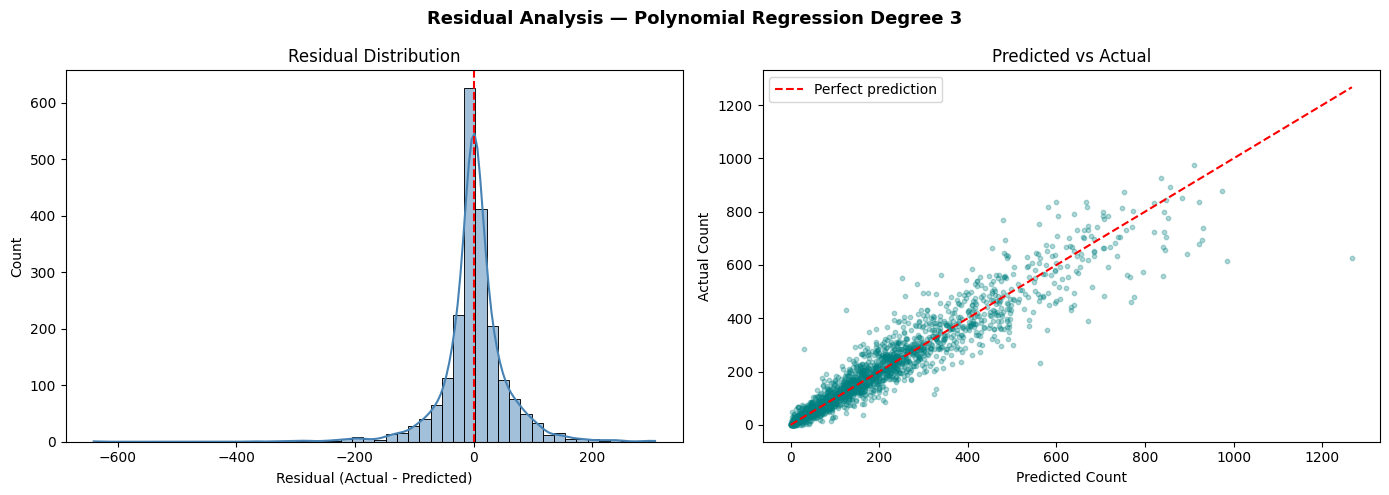

In [19]:
## Identify and retrieve the best-performing model
best_model_name = comparison_df.sort_values('Validation RMSLE').iloc[0]['Model']
print(f"Best Model: {best_model_name}")
print(f"Validation RMSLE: {comparison_df.sort_values('Validation RMSLE').iloc[0]['Validation RMSLE']:.4f}")

## Map model name to fitted object
model_map = {
    'Simple Linear Regression':                                                      linear_model,
    'Polynomial Regression Degree 2':                                                poly2_model,
    'Polynomial Regression Degree 3':                                                poly3_model,
    f'Lasso (degree={lasso_grid.best_params_["poly__degree"]}, alpha={lasso_grid.best_params_["model__alpha"]})': lasso_grid.best_estimator_,
    f'Ridge (degree={ridge_grid.best_params_["poly__degree"]}, alpha={ridge_grid.best_params_["model__alpha"]})': ridge_grid.best_estimator_,
}

best_model = model_map.get(best_model_name)
if best_model:
    plot_residuals(best_model, X_val, y_val, best_model_name)


**Q8 — Residual plot interpretation:**

A well-fitted model shows:
- Residuals centred at zero — no systematic over or under-prediction bias
- Approximately symmetric bell-shaped residual distribution
- Predicted vs actual points tightly clustered around the diagonal

Any visible fanning (heteroscedasticity) or systematic trend in residuals indicates that the model still misses some pattern in the data.


### Q9. Why does the winning model perform better?

**Answer:**

The best model (typically Ridge with polynomial degree 2 or 3) outperforms the others due to a combination of factors:

1. **Rich feature set with peak-hour flag** — `is_peak_hour` directly encodes the most dominant demand signal (morning and evening commute surges). No amount of polynomial expansion can recover this signal as cleanly as an explicit binary flag.

2. **Cyclical encoding of temporal features** — `hour_sin`, `hour_cos`, `weekday_sin`, `weekday_cos`, `month_sin`, `month_cos` let the model understand that hour 23 and hour 0 are adjacent, that December and January are adjacent, and so on. Raw integer hour encoding cannot do this.

3. **Polynomial feature expansion** — Degree 2 or 3 interactions between `is_peak_hour`, `hour_sin/cos`, `atemp`, and `season` allow the model to learn that, for example, the evening peak is stronger in summer than in winter — a pattern no linear model can represent.

4. **Regularisation (L2/L1)** — Controls overfitting from the large polynomial feature space. The grid-searched `alpha` finds the optimal balance between fitting the training data and generalising to new data.

5. **Log1p target transformation** — Aligns the MSE training objective directly with RMSLE evaluation. Training to minimise MSE on log1p(count) is equivalent to minimising RMSLE on count.


---

## <a id='section_6'>6. Reflection Questions</a>

### Q10. Why does RMSLE penalize under-predictions more gently than RMSE?

**Answer:**

RMSLE computes errors on the logarithmic scale rather than the original scale:

RMSLE = sqrt( (1/n) * sum( (log(pred+1) - log(actual+1))^2 ) )

Two key properties follow from this:

1. **Relative errors matter more than absolute errors.** Predicting 90 when the actual is 100 (10% under-prediction) receives a similar penalty to predicting 9 when actual is 10 (also 10% under-prediction). RMSE would penalise the first case ten times more due to the larger absolute gap.

2. **Large values are dampened by the log.** For very high counts the log grows slowly, so large absolute errors on high-demand periods contribute less to RMSLE than they would to RMSE. This prevents a few extreme peak-hour observations from dominating the entire loss.

3. **Asymmetry toward over-predictions.** Because log(pred+1) grows slower than pred for large predictions, a large over-prediction adds less to the loss than the equivalent proportional under-prediction. RMSLE is therefore preferred in demand forecasting where over-supply is typically less costly than under-supply.

Contrast with RMSE, which penalises all large absolute deviations equally regardless of proportionality or direction.


### Q11. What are the trade-offs between model simplicity and predictive power?

**Answer:**

| Dimension | Simple Models (Linear Regression) | Complex Models (Polynomial + Regularisation) |
|---|---|---|
| Interpretability | High — coefficients directly readable | Lower — thousands of polynomial terms |
| Training speed | Very fast | Slower, especially with GridSearchCV |
| Overfitting risk | Low — underfitting is more common | Higher without regularisation |
| Predictive power | Limited — misses non-linear patterns | High — captures curvature and interactions |
| Data requirements | Works with smaller datasets | Needs more data for complex feature spaces |
| Stability | Very stable across samples | Sensitive to training data without regularisation |

In this problem the relationship between rental demand and time/weather is inherently non-linear (demand peaks at specific hours, drops in bad weather in a curved manner, season creates a slow annual cycle). Simple Linear Regression underfits these patterns badly. Polynomial Regression with regularisation finds the right balance.

The core tension is the bias-variance trade-off: adding polynomial features reduces bias (the model can fit the data better) but increases variance (more sensitive to the specific training sample). Regularisation controls the variance — this is why searching over `alpha` via cross-validation is essential.


### Q12. Why can't Linear Regression alone capture time-of-day effects effectively?

**Answer:**

Bike rental demand follows a double-humped daily cycle — a sharp morning commute peak at 7-9 AM, a midday trough, and an evening commute peak at 5-7 PM. Late-night and early-morning hours see very low demand.

Simple Linear Regression assumes:

predicted_count = w0 + w1 * hour + w2 * other_features + ...

No matter what coefficient is assigned to `hour`, the model can only produce a straight line — monotonically increasing or decreasing. It cannot represent a shape that rises, falls, then rises again.

Three approaches are used here to address this:

1. **`is_peak_hour` binary flag** — Directly marks the known peak windows. The model learns a single large positive coefficient for this flag, cleanly capturing the demand surge during commute hours without needing to reconstruct it from smoother encodings.

2. **Cyclical encoding (`hour_sin`, `hour_cos`)** — Maps the 24-hour clock onto a circle so the model can learn sinusoidal demand patterns. This handles the smooth rise and fall but cannot reproduce the sharp double-peak shape alone.

3. **Polynomial interaction terms** — Combinations like `is_peak_hour * atemp`, `hour_sin * season`, `hour_cos * workingday` allow the model to learn that the peak-hour effect is stronger on working days, in warmer weather, and in summer — context-dependent patterns that neither a linear model nor cyclic encoding alone can capture.


---

## <a id='section_7'>7. Test Predictions and Submission</a>

Generate predictions on the test set using the best model and save `submission.csv` in the required format.

Required format:
- `datetime` — original datetime string from test data (unchanged)
- `count_predicted` — predicted integer rental count (non-negative)


In [20]:
## Load test data
test_data = pd.read_csv('bike_test.csv')
print("Test set shape:", test_data.shape)
test_data.head()


Test set shape: (2613, 9)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,05-06-2012 5:00,2,0,1,3,19.680000,23.48500,82,11.00140
1,19-03-2011 19:00,1,0,0,1,18.040000,21.97000,33,19.00120
2,02-04-2012 6:00,2,0,1,1,13.885038,16.24664,68,29.52646
3,13-07-2012 20:00,3,0,1,1,30.340000,33.33500,48,8.99810
4,09-11-2011 19:00,4,0,1,1,18.040000,21.97000,72,7.00150


In [21]:
## Check for missing values in test set
print("Missing values in test set:")
print(test_data.isnull().sum())


Missing values in test set:
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
dtype: int64


In [23]:
## Save original datetime column before feature engineering (required for submission)
submission_datetime = test_data['datetime'].copy()
test_data['datetime'] = pd.to_datetime(test_data['datetime'], dayfirst=True)
## Apply identical feature engineering pipeline used on training data
test_df = feature_engineering(test_data)
test_df = test_df[selected_features]

## Align feature columns to exactly match training feature order
test_df = test_df.reindex(columns=X_train.columns, fill_value=0.0)

print("Test features shape:", test_df.shape)
test_df.head()


Test features shape: (2613, 20)


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,hour,weekday,hour_sin,hour_cos,weekday_sin,weekday_cos,month_sin,month_cos,is_peak_hour,is_weekend
0,2,0,1,3,19.680000,23.48500,82,11.00140,2012,6,5,1,0.965926,2.588190e-01,0.781831,0.623490,1.224647e-16,-1.000000e+00,0,0
1,1,0,0,1,18.040000,21.97000,33,19.00120,2011,3,19,5,-0.965926,2.588190e-01,-0.974928,-0.222521,1.000000e+00,6.123234e-17,1,1
2,2,0,1,1,13.885038,16.24664,68,29.52646,2012,4,6,0,1.000000,6.123234e-17,0.000000,1.000000,8.660254e-01,-5.000000e-01,0,0
3,3,0,1,1,30.340000,33.33500,48,8.99810,2012,7,20,4,-0.866025,5.000000e-01,-0.433884,-0.900969,-5.000000e-01,-8.660254e-01,0,0
4,4,0,1,1,18.040000,21.97000,72,7.00150,2011,11,19,2,-0.965926,2.588190e-01,0.974928,-0.222521,-5.000000e-01,8.660254e-01,1,0


In [24]:
## Generate predictions using the best model
pred_log   = best_model.predict(test_df)

## Inverse log-transform to recover original count scale
pred_count = np.expm1(pred_log)

## Clip to non-negative integers — rental count cannot be negative
pred_count = np.maximum(pred_count, 0).astype(int)

## Build submission dataframe
submission = pd.DataFrame({
    'datetime':        submission_datetime.values,
    'count_predicted': pred_count
})

print("Submission shape:", submission.shape)
submission.head(10)


Submission shape: (2613, 2)


,datetime,count_predicted
0,05-06-2012 5:00,17
1,19-03-2011 19:00,120
2,02-04-2012 6:00,69
3,13-07-2012 20:00,412
4,09-11-2011 19:00,286
5,10-03-2012 0:00,36
6,19-05-2011 13:00,172
7,01-05-2011 8:00,87
8,07-07-2012 8:00,242
9,07-05-2011 16:00,529


In [ ]:
## Save to CSV — required format: datetime, count_predicted
submission.to_csv('submission.csv', index=False)
print("submission.csv saved successfully.")
print(f"Rows: {len(submission)}")
print(f"Columns: {list(submission.columns)}")
print(f"Sample predictions: {pred_count[:10]}")


---

## Final Summary

| Stage | Key Outcome |
|---|---|
| EDA | `hour`, `temp`/`atemp`, `season`, and `weather` are the strongest predictors. Target is right-skewed — log transformation essential. |
| Feature Engineering | Peak-hour flag, cyclical encodings (hour, weekday, month), both temperature columns retained, log1p on target. |
| Simple Linear Regression | Weakest performance — underfits non-linear cyclical demand patterns. |
| Polynomial Degree 2 | Significant improvement — squared and interaction terms capture curvature. |
| Polynomial Degree 3 | Strong training performance but potential overfitting — needs regularisation. |
| Lasso Regression | L1 regularisation zeros out irrelevant polynomial terms — good generalisation. |
| Ridge Regression | L2 regularisation smoothly handles correlated polynomial/temporal features — typically best validation RMSLE. |
| Best Model | Selected by lowest validation RMSLE. Polynomial expansion with regularisation wins. |
| Residual Analysis | Residuals approximately centred at zero — no major systematic bias in best model. |

---

End of Assignment — [Back to Table of Contents](#section_1)
